### Velocity Estimation with M = 0.2

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
from scipy.special import jv
import matplotlib.pyplot as plt
from time import time

Nf = 2500
adam_epochs = 2000
div0_threshold = 1e-6
f_set = [ 500 ]
c = 343.0
rho = 1.225
mu = 1.8e-5
cp = 1007.0
K_th = 0.02476
gamma = 1.4
a = 0.0005

k_set_complex = []
for f in f_set:
    omega = 2.0 * np.pi * f
    k_standard = omega / c
    
    k_v = np.sqrt( (-1j * omega * rho) / mu )
    k_h = np.sqrt( (-1j * omega * rho * cp) / K_th )
    
    phi_v = - ( jv(2, k_v * a) / jv(0, k_v * a) )
    phi_h = - ( jv(2, k_h * a) / jv(0, k_h * a) )
    
    k_w = k_standard * np.sqrt ( ( gamma - (gamma - 1.0) * phi_h) / phi_v )
    
    k_R = np.real ( k_w )
    k_I = np.imag ( k_w )
    
    k_set_complex.append ( ( k_R, k_I ) )

print ( k_set_complex )

torch.set_default_dtype ( torch.float64 )
device = torch.device ( "cuda" if torch.cuda.is_available() else "cpu" )
print ( device )

class LatentFNOLayer ( nn.Module ):
    def __init__ ( self, latent_dim = 128, modes = 8 ):
        super().__init__()
        self.latent_dim = latent_dim
        self.modes = modes
        
        self.expansion = nn.Linear ( 1, latent_dim )
        
        scale = 1.0 / ( latent_dim * modes )
        self.complex_weights = nn.Parameter (
            scale * torch.randn ( 1, modes, dtype = torch.cdouble )
        )
        
    def forward ( self, x ):        
        h = self.expansion ( x )
        h = F.gelu ( h ) 
        
        h_ft = torch.fft.rfft ( h, dim = -1 )
        
        out_ft = torch.zeros_like ( h_ft )
        out_ft[:, :self.modes] = h_ft[:, :self.modes] * self.complex_weights
        
        h_out = torch.fft.irfft ( out_ft, n = self.latent_dim, dim = -1 )
        
        return h_out

class Helmholtz_PINN ( nn.Module ):
    def __init__ ( self, n_bank = 64, n_hidden = 7 ):
        super().__init__()

        self.n_bank = n_bank
        self.n_hidden = n_hidden
        
        latent_dim = 2 * n_bank
        
        self.fno_input = LatentFNOLayer ( latent_dim = latent_dim, modes = 8 )
        
        self.layers = nn.ModuleList()

        for i in range ( n_hidden ):
            self.layers.append ( nn.Linear ( latent_dim, latent_dim ) )

        self.layers.append ( nn.Linear ( latent_dim, 2 ) )
        
        self.apply ( self.init_weights )

    def init_weights ( self, m ):
        if isinstance ( m, nn.Linear ):
            torch.nn.init.xavier_uniform_ ( m.weight )
            if m.bias is not None:
                m.bias.data.fill_ ( 0.0 )

    def forward ( self, x ):
        out = self.fno_input ( x )
        
        for i in range ( self.n_hidden ):
            out = torch.sin ( self.layers[i](out) )
            
        network_out = self.layers[-1](out)

        out_R = network_out[:, 0:1]
        out_I = network_out[:, 1:2]

        distance_func = x * ( 1.0 - x )
        
        p_R_hat = ( 1.0 - 2.0 * x ) + distance_func * out_R
        p_I_hat = 0.0 + distance_func * out_I
        
        return p_R_hat, p_I_hat

def net_loss ( model, x, k_R, k_I, M = 0.2, return_pointwise = False ):
    p_R, p_I = model ( x )
    
    dp_R_dx = torch.autograd.grad (
        p_R, x, grad_outputs = torch.ones_like ( p_R ),
        create_graph = True, retain_graph = True
    )[0]
    
    dp_I_dx = torch.autograd.grad (
        p_I, x, grad_outputs = torch.ones_like ( p_I ),
        create_graph = True, retain_graph = True
    )[0]
    
    d2p_R_dx2 = torch.autograd.grad (
        dp_R_dx, x, grad_outputs = torch.ones_like ( dp_R_dx ),
        create_graph = True, retain_graph = True
    )[0]
    
    d2p_I_dx2 = torch.autograd.grad (
        dp_I_dx, x, grad_outputs = torch.ones_like ( dp_I_dx ),
        create_graph = True, retain_graph = True
    )[0]
    
    term1_R = ( 1.0 - M**2 ) * d2p_R_dx2
    term1_I = ( 1.0 - M**2 ) * d2p_I_dx2
    
    term2_R = 2.0 * M * ( k_R * dp_I_dx + k_I * dp_R_dx )
    term2_I = 2.0 * M * ( -k_R * dp_R_dx + k_I * dp_I_dx )
    
    term3_R = ( k_R**2 - k_I**2 ) * p_R - 2.0 * k_R * k_I * p_I
    term3_I = ( k_R**2 - k_I**2 ) * p_I + 2.0 * k_R * k_I * p_R
    
    res_R = ( term1_R + term2_R + term3_R ) / k_R
    res_I = ( term1_I + term2_I + term3_I ) / k_R
    
    total_res = res_R**2 + res_I**2
    
    if return_pointwise:
        return torch.sqrt ( total_res )
    return torch.mean ( total_res )

x_f_base = torch.linspace ( 0, 1, Nf, device = device ).view ( -1, 1 )

models = []
loss_histories = []

model = Helmholtz_PINN ( n_bank = 65, n_hidden = 7 ).to ( device )

start = time()

for k_r, k_i in k_set_complex:
    
    x_f = x_f_base.clone()
    x_f.requires_grad = True

    adam_opt = torch.optim.Adam ( model.parameters(), lr = 0.001, weight_decay = 1e-5 )

    loss_history = []

    print ( "INFO: Adam Training Started For k_r = {:.2f}, k_i = {:.2f}".format ( k_r, k_i ) )    
    for epoch in range ( adam_epochs ):
        adam_opt.zero_grad()
        loss = net_loss ( model, x_f, k_r, k_i, M = 0.2 )
        loss.backward()
        adam_opt.step()
        
        loss_history.append ( loss.item() )
        
        if ( epoch + 1 ) % 200 == 0:
            with torch.no_grad():
                x_candidate = torch.linspace ( 0, 1, 5000, device = device ).view ( -1, 1 )
            x_candidate.requires_grad = True
            
            abs_residual = net_loss ( model, x_candidate, k_r, k_i, M = 0.2, return_pointwise = True )
            
            _, top_indices = torch.topk ( abs_residual.flatten(), 50 )
            x_f = torch.cat ( [ x_f.detach(), x_candidate[top_indices].detach() ], dim = 0 )
            x_f.requires_grad = True
            print ( "INFO: k_r = {:.2f}, k_i = {:.2f}; Iteration: {}; Loss: {}; Time: {}".format ( k_r, k_i, len ( loss_history ), loss.item(), time() - start ) )

    print ( "INFO: Adam Training Done For k_r = {:.2f}, k_i = {:.2f}\n".format ( k_r, k_i ) )

    define_iters = int ( 200 * k_r )
    if ( k_r >= 50 ):
        define_iters += 5000

    opt = torch.optim.LBFGS (
        model.parameters(),
        lr = 1.0,
        max_iter = define_iters,
        line_search_fn = "strong_wolfe" )

    def closure():
        opt.zero_grad()
        loss = net_loss ( model, x_f, k_r, k_i, M = 0.2 )
        loss.backward()
        
        loss_history.append ( loss.item() )
        if len ( loss_history ) % 1000 == 0:
            print ( "INFO: Iteration: {}; Loss: {}; Time: {}".format ( len ( loss_history ), loss.item(), time() - start ) )
        return loss

    print ( "INFO: LBFGS Training Started For k_r = {:.2f}, k_i = {:.2f}\n".format ( k_r, k_i ) )
    opt.step ( closure )
    print ( "INFO: LBFGS Training Done For k_r = {:.2f}, k_i = {:.2f}\n".format ( k_r, k_i ) )
    
    models.append ( copy.deepcopy ( model ) )
    loss_histories.append ( loss_history )

[(np.float64(10.440530828137401), np.float64(-1.503745337719519))]
cuda
INFO: Adam Training Started For k_r = 10.44, k_i = -1.50
INFO: k_r = 10.44, k_i = -1.50; Iteration: 200; Loss: 3.219092482356824; Time: 28.931484937667847
INFO: k_r = 10.44, k_i = -1.50; Iteration: 400; Loss: 0.42022305033128965; Time: 58.33365082740784
INFO: k_r = 10.44, k_i = -1.50; Iteration: 600; Loss: 0.024989385879592874; Time: 90.77436947822571
INFO: k_r = 10.44, k_i = -1.50; Iteration: 800; Loss: 0.007688047639578607; Time: 123.98865008354187
INFO: k_r = 10.44, k_i = -1.50; Iteration: 1000; Loss: 0.009322220355190662; Time: 157.34399700164795
INFO: k_r = 10.44, k_i = -1.50; Iteration: 1200; Loss: 0.08818189975085512; Time: 191.3607587814331
INFO: k_r = 10.44, k_i = -1.50; Iteration: 1400; Loss: 0.06740299046683859; Time: 225.61728739738464
INFO: k_r = 10.44, k_i = -1.50; Iteration: 1600; Loss: 0.005019802629104282; Time: 260.16778349876404
INFO: k_r = 10.44, k_i = -1.50; Iteration: 1800; Loss: 0.07553945161

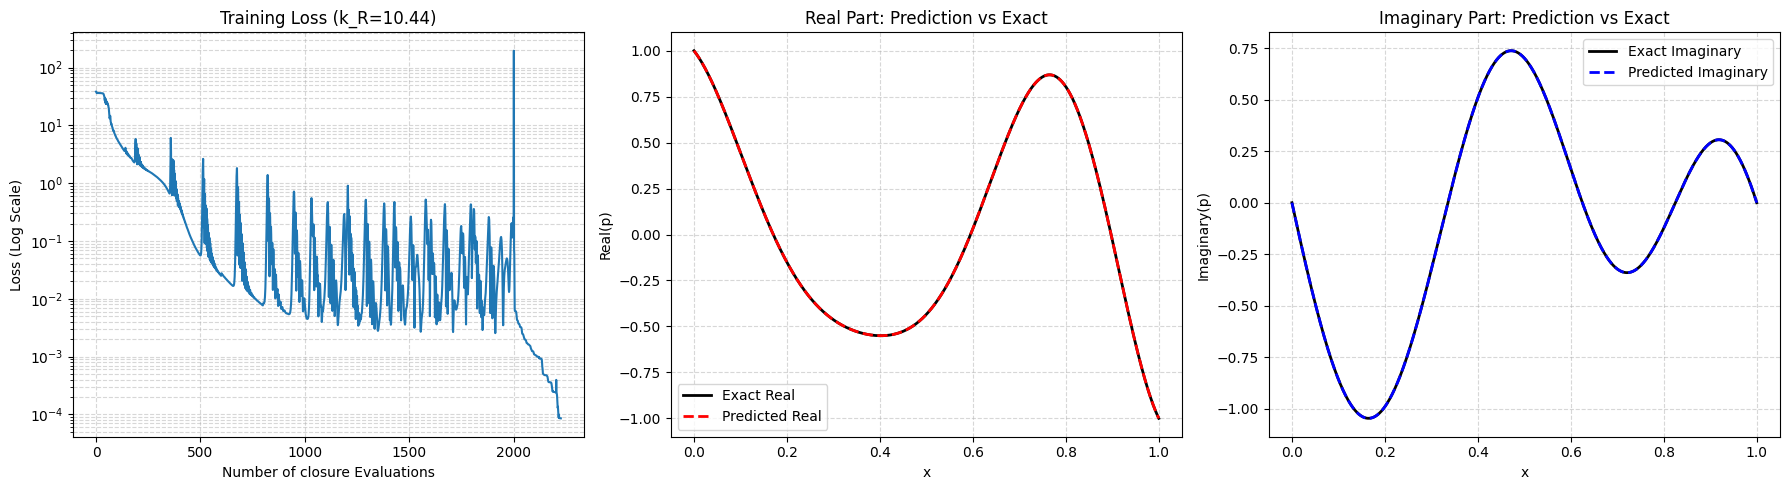

In [47]:
def exact_solution ( x, k_w, M = 0.2 ):
    k_plus = k_w / ( 1.0 + M )
    k_minus = k_w / ( 1.0 - M )
    
    denom = np.exp ( 1j * k_minus ) - np.exp ( -1j * k_plus )
    C1 = ( 1.0 + np.exp ( 1j * k_minus ) ) / denom
    C2 = 1.0 - C1
    
    return C1 * np.exp ( -1j * k_plus * x ) + C2 * np.exp ( 1j * k_minus * x )

for i, ( k_R, k_I ) in enumerate ( k_set_complex ): 
    model = models[i]
    loss_history = loss_histories[i]
    
    k_w = k_R + 1j * k_I

    with torch.no_grad():
        x_plot = torch.linspace ( 0, 1, 2000, device = device ).view ( -1, 1 )
        x_eval = x_plot.cpu().numpy().flatten()
        
        pred_R, pred_I = model ( x_plot )
        pred_R_eval = pred_R.cpu().numpy().flatten()
        pred_I_eval = pred_I.cpu().numpy().flatten()
        
        exact_complex = exact_solution ( x_eval, k_w, M = 0.2 )
        exact_R_eval = np.real ( exact_complex )
        exact_I_eval = np.imag ( exact_complex )

    fig, axs = plt.subplots ( 1, 3, figsize = (18, 5) )

    axs[0].plot ( loss_history )
    axs[0].set_yscale ( "log" )
    axs[0].set_xlabel ( "Number of closure Evaluations" )
    axs[0].set_ylabel ( "Loss (Log Scale)" )
    axs[0].set_title ( f"Training Loss (k_R={k_R:.2f})" )
    axs[0].grid ( True, which = "both", linestyle="--", alpha = 0.5 )

    axs[1].plot ( x_eval, exact_R_eval, 'k-', linewidth = 2, label = "Exact Real" )
    axs[1].plot ( x_eval, pred_R_eval, '--', color = 'red', linewidth = 2, label = "Predicted Real" )
    axs[1].set_xlabel ( "x" )
    axs[1].set_ylabel ( "Real(p)" )
    axs[1].set_title ( "Real Part: Prediction vs Exact" )
    axs[1].grid ( True, linestyle = "--", alpha = 0.5 )
    axs[1].legend()

    axs[2].plot ( x_eval, exact_I_eval, 'k-', linewidth = 2, label = "Exact Imaginary" )
    axs[2].plot ( x_eval, pred_I_eval, '--', color = 'blue', linewidth = 2, label = "Predicted Imaginary" )
    axs[2].set_xlabel ( "x" )
    axs[2].set_ylabel ( "Imaginary(p)" )
    axs[2].set_title ( "Imaginary Part: Prediction vs Exact" )
    axs[2].grid ( True, linestyle = "--", alpha = 0.5 )
    axs[2].legend()

    plt.tight_layout()
    plt.show()

In [48]:
def torch_exact_solution ( x, k_w, M = 0.2 ):
    x_cpu = x.cpu().numpy().flatten()
    
    k_plus = k_w / ( 1.0 + M )
    k_minus = k_w / ( 1.0 - M )
    
    denom = np.exp ( 1j * k_minus ) - np.exp ( -1j * k_plus )
    C1 = ( 1.0 + np.exp ( 1j * k_minus ) ) / denom
    C2 = 1.0 - C1
    
    exact_complex = C1 * np.exp ( -1j * k_plus * x_cpu ) + C2 * np.exp ( 1j * k_minus * x_cpu )
    
    p_true_R = torch.from_numpy ( np.real ( exact_complex ) ).view ( -1, 1 ).to ( x.device, dtype = x.dtype )
    p_true_I = torch.from_numpy ( np.imag ( exact_complex ) ).view ( -1, 1 ).to ( x.device, dtype = x.dtype )
    
    return p_true_R, p_true_I

N_eval = 5000
x_eval = torch.linspace ( 0, 1, N_eval, device = device ).view ( -1, 1 )

for i, ( k_R, k_I ) in enumerate ( k_set_complex ):
    current_model = models[i]
    current_model.eval()
    
    k_w = k_R + 1j * k_I
    
    with torch.no_grad():
        p_pred_R, p_pred_I = current_model ( x_eval )
        p_true_R, p_true_I = torch_exact_solution ( x_eval, k_w, M = 0.2 )
        
        error_R = p_true_R - p_pred_R
        error_I = p_true_I - p_pred_I
        
        error_norm = torch.sqrt ( torch.sum ( error_R ** 2 + error_I ** 2 ) )
        true_norm = torch.sqrt ( torch.sum ( p_true_R ** 2 + p_true_I ** 2 ) )
        
        relative_l2_error = ( error_norm / true_norm ).item()
        
    print ( f"k_R = {k_R:.2f}, k_I = {k_I:.2f} - Relative L2 Error: {relative_l2_error}" )

k_R = 10.44, k_I = -1.50 - Relative L2 Error: 0.0001801488841107093


In [49]:
def velocity_loss ( vel_model, press_model, x, k_R, k_I, M = 0.2, rho_c = 415.0 ):
    p_R, p_I = press_model ( x )
    
    dp_R_dx = torch.autograd.grad (
        p_R, x, grad_outputs = torch.ones_like ( p_R ),
        create_graph = True, retain_graph = True
     )[0]
    
    dp_I_dx = torch.autograd.grad (
        p_I, x, grad_outputs = torch.ones_like ( p_I ),
        create_graph = True, retain_graph = True
     )[0]

    u_R, u_I = vel_model ( x )
    
    du_R_dx = torch.autograd.grad (
        u_R, x, grad_outputs = torch.ones_like ( u_R ),
        create_graph = True, retain_graph = True
     )[0]
    
    du_I_dx = torch.autograd.grad (
        u_I, x, grad_outputs = torch.ones_like ( u_I ),
        create_graph = True, retain_graph = True
     )[0]

    res_mom_R = rho_c * ( M * du_R_dx - k_R * u_I - k_I * u_R ) + dp_R_dx
    res_mom_I = rho_c * ( M * du_I_dx + k_R * u_R - k_I * u_I ) + dp_I_dx
    
    res_cont_R = rho_c * du_R_dx + M * dp_R_dx - k_R * p_I - k_I * p_R
    res_cont_I = rho_c * du_I_dx + M * dp_I_dx + k_R * p_R - k_I * p_I

    return torch.mean ( res_mom_R**2 + res_mom_I**2 + res_cont_R**2 + res_cont_I**2 )

In [50]:
class LearnableSpectralLayer ( nn.Module ):
    def __init__ ( self, in_features, num_modes ):
        super().__init__()
        B_init = torch.randn ( in_features, num_modes ) * 10.0 
        self.B = nn.Parameter ( B_init )
        
    def forward ( self, x ):
        spectral_projection = torch.matmul ( x, self.B )
        
        return torch.cat ( [ torch.sin(spectral_projection), torch.cos(spectral_projection) ], dim = -1 )


class Velocity_PINN ( nn.Module ):
    def __init__ ( self, n_bank, n_hidden ):
        super().__init__()
        self.n_bank = n_bank
        self.n_hidden = n_hidden
        
        self.spectral_layer = LearnableSpectralLayer ( in_features = 1, num_modes = self.n_bank )
        
        self.layers = nn.ModuleList()
        self.layers.append ( nn.Linear ( 2*n_bank, 2*n_bank ) )
        for i in range ( n_hidden ):
            self.layers.append ( nn.Linear ( 2*n_bank, 2*n_bank ) )
            
        # 2 Outputs (Real and Imaginary Velocity)
        self.layers.append ( nn.Linear ( 2*n_bank, 2 ) )
        self.apply ( self.init_weights )

    def init_weights(self, m):
        if isinstance ( m, nn.Linear ):
            torch.nn.init.xavier_uniform_ ( m.weight )
            if m.bias is not None:
                m.bias.data.fill_ ( 0.0 )

    def forward ( self, x ):
        out = self.spectral_layer ( x )
        
        for i in range ( self.n_hidden + 1 ):
            out = torch.sin ( self.layers[i](out) )
        network_out = self.layers[-1](out)

        out_R = network_out[:, 0:1]
        out_I = network_out[:, 1:2]

        return out_R, out_I

In [51]:
trained_pressure_model = models[0] 
k_r_val = k_set_complex[0][0]
k_i_val = k_set_complex[0][1]

for param in trained_pressure_model.parameters():
    param.requires_grad = False
trained_pressure_model.eval()

vel_model = Velocity_PINN ( n_bank = 65, n_hidden = 7 ).to ( device )
adam_opt = torch.optim.Adam ( vel_model.parameters(), lr = 0.001 )

x_f = torch.linspace ( 0, 1, 2500, device = device ).view ( -1, 1 )
x_f.requires_grad = True
vel_loss_history = []

print ( "INFO: Velocity: Adam Iteration for k_r = {:.2f}, k_i = {:.2f}".format ( k_r_val, k_i_val ) )

for epoch in range ( 2000 ):
    adam_opt.zero_grad()
    
    loss = velocity_loss ( vel_model, trained_pressure_model, x_f, k_r_val, k_i_val, M = 0.2 )
    
    loss.backward()
    adam_opt.step()
    vel_loss_history.append ( loss.item() )
    
    if ( epoch + 1 ) % 200 == 0:
         print ( "INFO: Adam Iteration: {}; Loss: {}".format ( epoch + 1, loss.item() ) )

print ( "INFO: Velocity: Adam Complete\n" )

opt_vel = torch.optim.LBFGS ( 
    vel_model.parameters(), 
    lr = 1.0, 
    max_iter = 5000, 
    line_search_fn = "strong_wolfe" )

def vel_closure():
    opt_vel.zero_grad()
    loss = velocity_loss ( vel_model, trained_pressure_model, x_f, k_r_val, k_i_val, M = 0.2 )
    loss.backward()
    vel_loss_history.append ( loss.item() )
    if len ( vel_loss_history ) % 1000 == 0:
            print ( "INFO: LBFGS Iteration: {}; Loss: {}".format ( len ( loss_history ), loss.item() ) )
    return loss

print ( "INFO: LBFGS Started" )
opt_vel.step ( vel_closure )
print ( "INFO: LBFGS Complete. Final Loss: {}".format ( vel_loss_history[-1] ) )

INFO: Velocity: Adam Iteration for k_r = 10.44, k_i = -1.50
INFO: Adam Iteration: 200; Loss: 194497.5214793334
INFO: Adam Iteration: 400; Loss: 34.17163124128513
INFO: Adam Iteration: 600; Loss: 17.652161044881606
INFO: Adam Iteration: 800; Loss: 18.340237787036383
INFO: Adam Iteration: 1000; Loss: 8.979115003344795
INFO: Adam Iteration: 1200; Loss: 6.121206015146845
INFO: Adam Iteration: 1400; Loss: 211671.43562193372
INFO: Adam Iteration: 1600; Loss: 7.596916376882585
INFO: Adam Iteration: 1800; Loss: 3.7333000202475968
INFO: Adam Iteration: 2000; Loss: 2.826722757176406
INFO: Velocity: Adam Complete

INFO: LBFGS Started
INFO: LBFGS Iteration: 2227; Loss: 0.007920450223901676
INFO: LBFGS Iteration: 2227; Loss: 0.0015959123296873283
INFO: LBFGS Iteration: 2227; Loss: 0.0006777004790537852
INFO: LBFGS Iteration: 2227; Loss: 0.0004589322889495257
INFO: LBFGS Iteration: 2227; Loss: 0.00026546610274942237
INFO: LBFGS Complete. Final Loss: 0.0002615203843229106


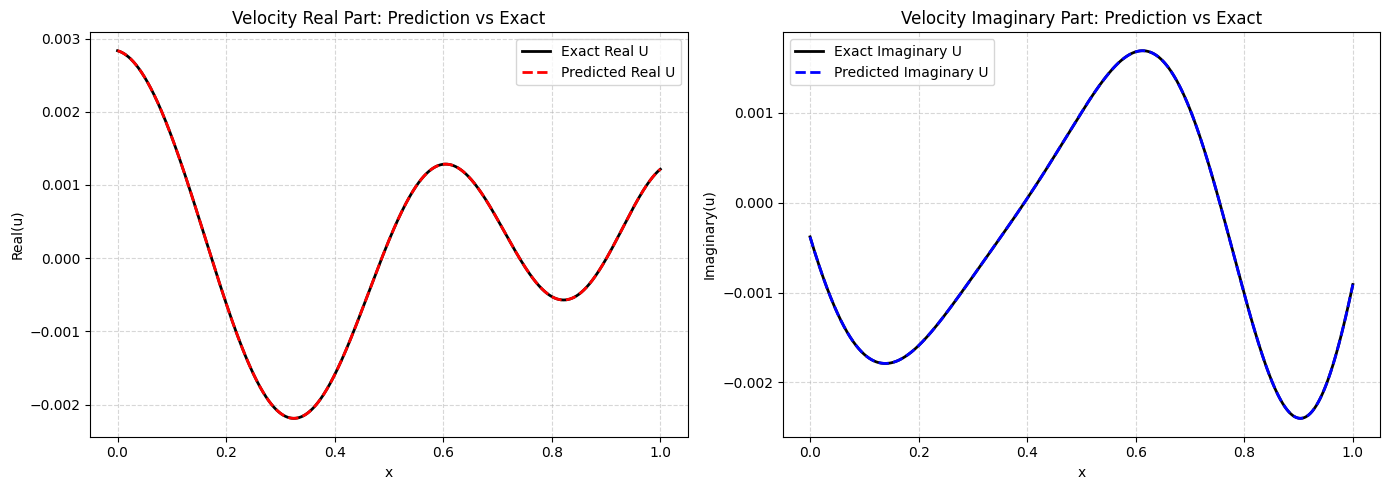

In [52]:
def exact_velocity_solution ( x, k_w, M = 0.2, rho_c = 415.0 ):
        k_plus = k_w / ( 1.0 + M )
        k_minus = k_w / ( 1.0 - M )
        
        denom = np.exp ( 1j * k_minus ) - np.exp ( -1j * k_plus )
        C1 = ( 1.0 + np.exp ( 1j * k_minus ) ) / denom
        C2 = 1.0 - C1
        
        u_complex = ( C1 * np.exp ( -1j * k_plus * x ) - C2 * np.exp ( 1j * k_minus * x ) ) / rho_c
        return u_complex
    
with torch.no_grad():
    x_plot = torch.linspace ( 0, 1, 2000, device = device ).view ( -1, 1 )
    x_eval = x_plot.cpu().numpy().flatten()
    
    pred_R, pred_I = vel_model ( x_plot )
    pred_R_eval = pred_R.cpu().numpy().flatten()
    pred_I_eval = pred_I.cpu().numpy().flatten()
    
    k_w_val = k_r_val + 1j * k_i_val
    exact_complex = exact_velocity_solution ( x_eval, k_w_val, M = 0.2 )
    exact_R_eval = np.real ( exact_complex )
    exact_I_eval = np.imag ( exact_complex )

fig, axs = plt.subplots ( 1, 2, figsize = (14, 5) )

axs[0].plot ( x_eval, exact_R_eval, 'k-', linewidth = 2, label = "Exact Real U" )
axs[0].plot ( x_eval, pred_R_eval, '--', color = 'red', linewidth = 2, label = "Predicted Real U" )
axs[0].set_xlabel ( "x" )
axs[0].set_ylabel ( "Real(u)" )
axs[0].set_title ( "Velocity Real Part: Prediction vs Exact" )
axs[0].grid ( True, linestyle = "--", alpha = 0.5 )
axs[0].legend()

axs[1].plot ( x_eval, exact_I_eval, 'k-', linewidth = 2, label = "Exact Imaginary U" )
axs[1].plot ( x_eval, pred_I_eval, '--', color = 'blue', linewidth = 2, label = "Predicted Imaginary U" )
axs[1].set_xlabel ( "x" )
axs[1].set_ylabel ( "Imaginary(u)" )
axs[1].set_title ( "Velocity Imaginary Part: Prediction vs Exact" )
axs[1].grid ( True, linestyle = "--", alpha = 0.5 )
axs[1].legend()

plt.tight_layout()
plt.show()

In [54]:
def compute_complex_relative_l2 ( pred_R, pred_I, true_R, true_I ):
    error_R = true_R - pred_R
    error_I = true_I - pred_I
    
    error_norm = torch.sqrt ( torch.sum ( error_R ** 2 + error_I ** 2 ) )
    true_norm = torch.sqrt ( torch.sum ( true_R ** 2 + true_I ** 2 ) )
    
    return ( error_norm / true_norm ).item()

N_eval = 5000
x_eval = torch.linspace ( 0, 1, N_eval, device = device ).view ( -1, 1 )

with torch.no_grad():
    p_pred_R, p_pred_I = current_model ( x_eval )
    
    p_true_R, p_true_I = torch_exact_solution ( x_eval, k_w, M = 0.2 )
    
    relative_l2_error = compute_complex_relative_l2 ( p_pred_R, p_pred_I, p_true_R, p_true_I )

print ( f"Relative L2 Error: {relative_l2_error}" )

Relative L2 Error: 0.0001801488841107093
